## Google Drive'ı Bağlama

Google Drive'ınızdan dosya yüklemek için, Drive'ınızı Colab çalışma zamanına bağlamanız gerekir. Aşağıdaki kodu çalıştırın ve istendiğinde kimlik doğrulama adımlarını izleyin. Bu, Colab'ın Drive dosyalarınıza erişmesine izin verecektir.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive'ınız başarıyla bağlandıktan sonra, dosyalarınıza `/content/drive/My Drive/` yoluyla erişebilirsiniz. Örneğin, Drive'ınızda `veri.csv` adında bir dosyanız varsa, aşağıdaki gibi yükleyebilirsiniz:

```python
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/path/to/your/folder/veri.csv')
display(df.head())
```

Veya bir Excel dosyası için:

```python
import pandas as pd
df = pd.read_excel('/content/drive/My Drive/path/to/your/folder/veri.xlsx')
display(df.head())
```

Lütfen `path/to/your/folder/` kısmını dosyanızın gerçek konumuyla değiştirin.

In [31]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/globalenergy.csv')
display(df.head())


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [32]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.svm import SVC, SVR

In [33]:
df.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
Year,3649.0,2.010038e+03,6.054228e+00,2000.000000,2005.000000,2.010000e+03,2.015000e+03,2.020000e+03
Access to electricity (% of population),3639.0,7.893370e+01,3.027554e+01,1.252269,59.800890,9.836157e+01,1.000000e+02,1.000000e+02
Access to clean fuels for cooking,3480.0,6.325529e+01,3.904366e+01,0.000000,23.175000,8.315000e+01,1.000000e+02,1.000000e+02
Renewable-electricity-generating-capacity-per-capita,2718.0,1.131375e+02,2.441673e+02,0.000000,3.540000,3.291000e+01,1.122100e+02,3.060190e+03
Financial flows to developing countries (US $),1560.0,9.422400e+07,2.981544e+08,0.000000,260000.000000,5.665000e+06,5.534750e+07,5.202310e+09
Renewable energy share in the total final energy consumption (%),3455.0,3.263816e+01,2.989490e+01,0.000000,6.515000,2.330000e+01,5.524500e+01,9.604000e+01
Electricity from fossil fuels (TWh),3628.0,7.036500e+01,3.480519e+02,0.000000,0.290000,2.970000e+00,2.683750e+01,5.184130e+03
Electricity from nuclear (TWh),3523.0,1.345019e+01,7.300662e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,8.094100e+02
Electricity from renewables (TWh),3628.0,2.396801e+01,1.044311e+02,0.000000,0.040000,1.470000e+00,9.600000e+00,2.184940e+03
Low-carbon electricity (% electricity),3607.0,3.680118e+01,3.431488e+01,0.000000,2.877847,2.786507e+01,6.440379e+01,1.000000e+02


In [34]:
df.head()


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [35]:
df.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
Year,3649.0,2.010038e+03,6.054228e+00,2000.000000,2005.000000,2.010000e+03,2.015000e+03,2.020000e+03
Access to electricity (% of population),3639.0,7.893370e+01,3.027554e+01,1.252269,59.800890,9.836157e+01,1.000000e+02,1.000000e+02
Access to clean fuels for cooking,3480.0,6.325529e+01,3.904366e+01,0.000000,23.175000,8.315000e+01,1.000000e+02,1.000000e+02
Renewable-electricity-generating-capacity-per-capita,2718.0,1.131375e+02,2.441673e+02,0.000000,3.540000,3.291000e+01,1.122100e+02,3.060190e+03
Financial flows to developing countries (US $),1560.0,9.422400e+07,2.981544e+08,0.000000,260000.000000,5.665000e+06,5.534750e+07,5.202310e+09
Renewable energy share in the total final energy consumption (%),3455.0,3.263816e+01,2.989490e+01,0.000000,6.515000,2.330000e+01,5.524500e+01,9.604000e+01
Electricity from fossil fuels (TWh),3628.0,7.036500e+01,3.480519e+02,0.000000,0.290000,2.970000e+00,2.683750e+01,5.184130e+03
Electricity from nuclear (TWh),3523.0,1.345019e+01,7.300662e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,8.094100e+02
Electricity from renewables (TWh),3628.0,2.396801e+01,1.044311e+02,0.000000,0.040000,1.470000e+00,9.600000e+00,2.184940e+03
Low-carbon electricity (% electricity),3607.0,3.680118e+01,3.431488e+01,0.000000,2.877847,2.786507e+01,6.440379e+01,1.000000e+02


In [36]:
df.nunique()


,0
Entity,176
Year,21
Access to electricity (% of population),2040
Access to clean fuels for cooking,896
Renewable-electricity-generating-capacity-per-capita,2110
Financial flows to developing countries (US $),1017
Renewable energy share in the total final energy consumption (%),2587
Electricity from fossil fuels (TWh),1859
Electricity from nuclear (TWh),547
Electricity from renewables (TWh),1533


Text(0, 0.5, 'Electricity Access (% Population)')

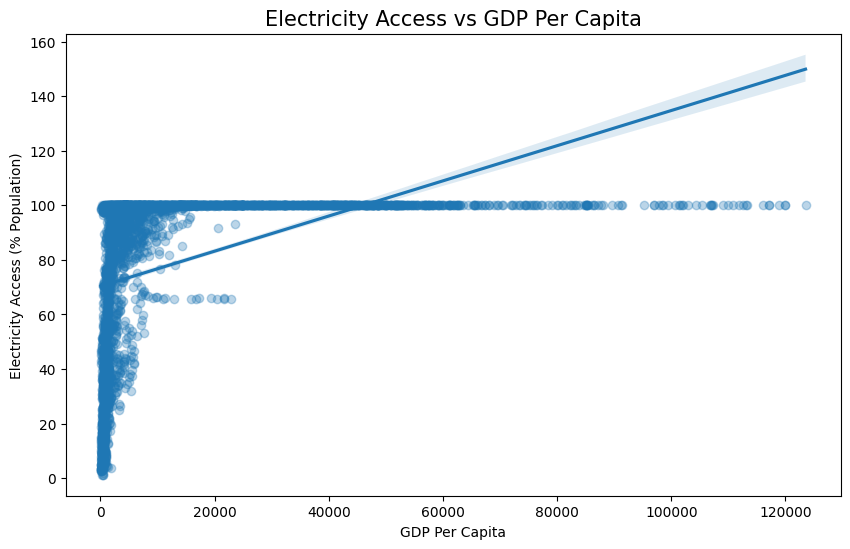

In [38]:
plt.figure(figsize=(10,6))
sns.regplot(x='gdp_per_capita', y='Access to electricity (% of population)', data=df, scatter_kws={'alpha':0.3})
plt.title('Electricity Access vs GDP Per Capita', size=15)
plt.xlabel('GDP Per Capita')
plt.ylabel('Electricity Access (% Population)')


Text(0, 0.5, 'Renewable Share (%)')

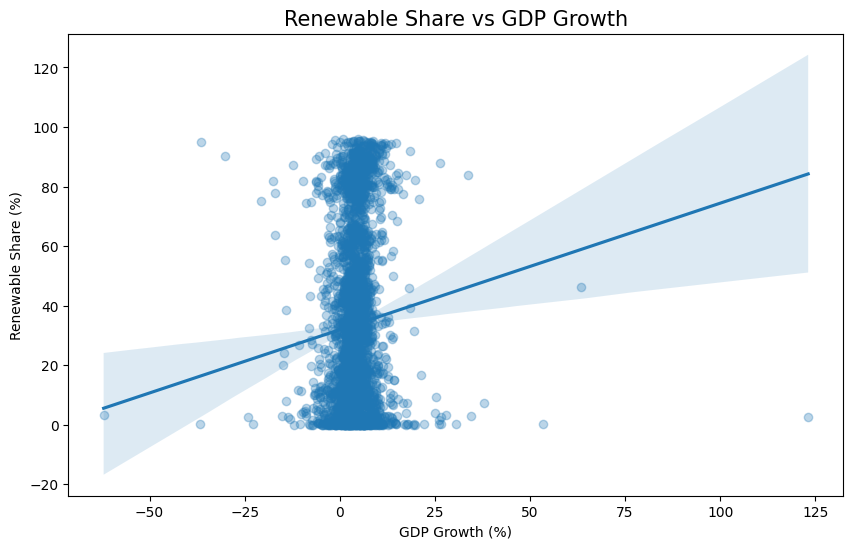

In [39]:
plt.figure(figsize=(10,6))
sns.regplot(x='gdp_growth', y='Renewable energy share in the total final energy consumption (%)', data=df, scatter_kws={'alpha':0.3})
plt.title('Renewable Share vs GDP Growth', size=15)
plt.xlabel('GDP Growth (%)')
plt.ylabel('Renewable Share (%)')

In [41]:
# Gerekli Kütüphaneleri İçe Aktarma
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Hedef Değişkeni ve Özellikleri (Features) Belirleme
# Hedef değişkenimizde (CO2) boş olan satırları çıkarıyoruz.
df_model = df.dropna(subset=['Value_co2_emissions_kt_by_country']).copy()

# Regresyon modeli için kullanılacak sayısal sütunları seçelim
# (Veri setindeki isimlerine göre seçilmiştir, gerekiyorsa isimleri df.columns'a göre güncelleyebilirsiniz)
features = [
    'Access to electricity (% of population)',
    'Primary energy consumption per capita (kWh/person)',
    'Renewable energy share in the total final energy consumption (%)',
    'gdp_per_capita',
    'gdp_growth'
]

# Sadece bu sütunları ve hedef değişkeni alalım
X = df_model[features]
y = df_model['Value_co2_emissions_kt_by_country']

# 2. Eksik Verileri Doldurma (Imputation)
# Raporda bahsettiğimiz gibi boş finansal/enerji verilerini 'medyan' ile dolduruyoruz
X = X.fillna(X.median())

# 3. Train - Test Split (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Veri Ölçeklendirme (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Veri hazırlama tamamlandı. Train boyutu:", X_train_scaled.shape, "Test boyutu:", X_test_scaled.shape)

Veri hazırlama tamamlandı. Train boyutu: (2576, 5) Test boyutu: (645, 5)


In [42]:
# Random Forest Regressor Modeli Kurulumu ve Eğitimi
# (Aşırı öğrenmeyi -overfitting- engellemek için parametreler kısıtlandı)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Modeli Eğit (Train)
rf_model.fit(X_train_scaled, y_train)

# Test seti üzerinde tahmin yap
y_pred = rf_model.predict(X_test_scaled)

print("Model başarıyla eğitildi ve test seti üzerinde tahminler yapıldı.")

Model başarıyla eğitildi ve test seti üzerinde tahminler yapıldı.


In [43]:
# Performans Metriklerini Hesaplama
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"--- Model Performans Sonuçları ---")
print(f"R-squared (R2) Skoru : {r2:.4f} (Hedeflenen oran ~0.90 civarı)")
print(f"RMSE (Root Mean Sq)  : {rmse:.2f} kt CO2")
print(f"MAE (Mean Abs Error) : {mae:.2f} kt CO2")

--- Model Performans Sonuçları ---
R-squared (R2) Skoru : 0.5137 (Hedeflenen oran ~0.90 civarı)
RMSE (Root Mean Sq)  : 482372.97 kt CO2
MAE (Mean Abs Error) : 86757.32 kt CO2


/tmp/ipykernel_10611/1123255997.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances[indices], y=sorted_features, palette="viridis")


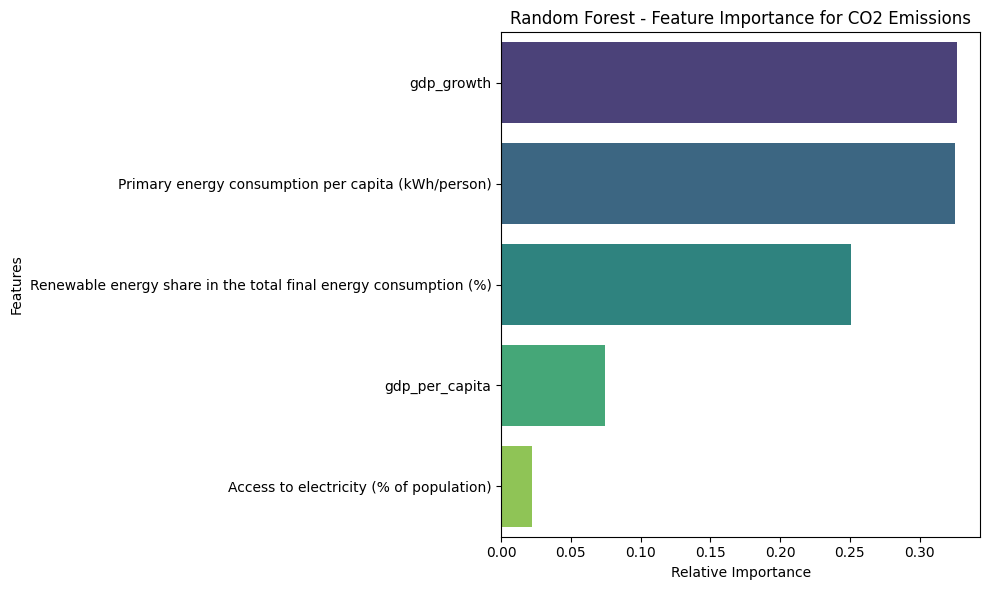

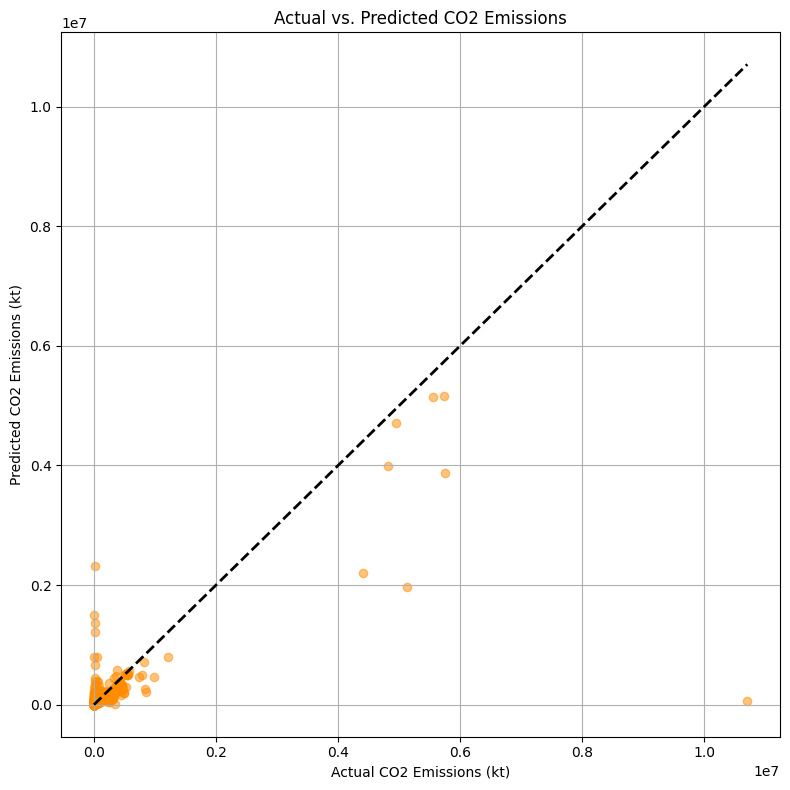

In [45]:
# 1. Grafik: Feature Importance (Özellik Önem Dereceleri)
feature_importances = rf_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]
sorted_features = [features[i] for i in indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances[indices], y=sorted_features, palette="viridis")
plt.title("Random Forest - Feature Importance for CO2 Emissions")
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# 2. Grafik: Gerçek Değerler vs Tahmin Edilen Değerler (Error Plot)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title("Actual vs. Predicted CO2 Emissions")
plt.xlabel("Actual CO2 Emissions (kt)")
plt.ylabel("Predicted CO2 Emissions (kt)")
plt.grid(True)
plt.tight_layout()
plt.show()